✅ Data loaded successfully from remote source!

--- Dataset Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-n

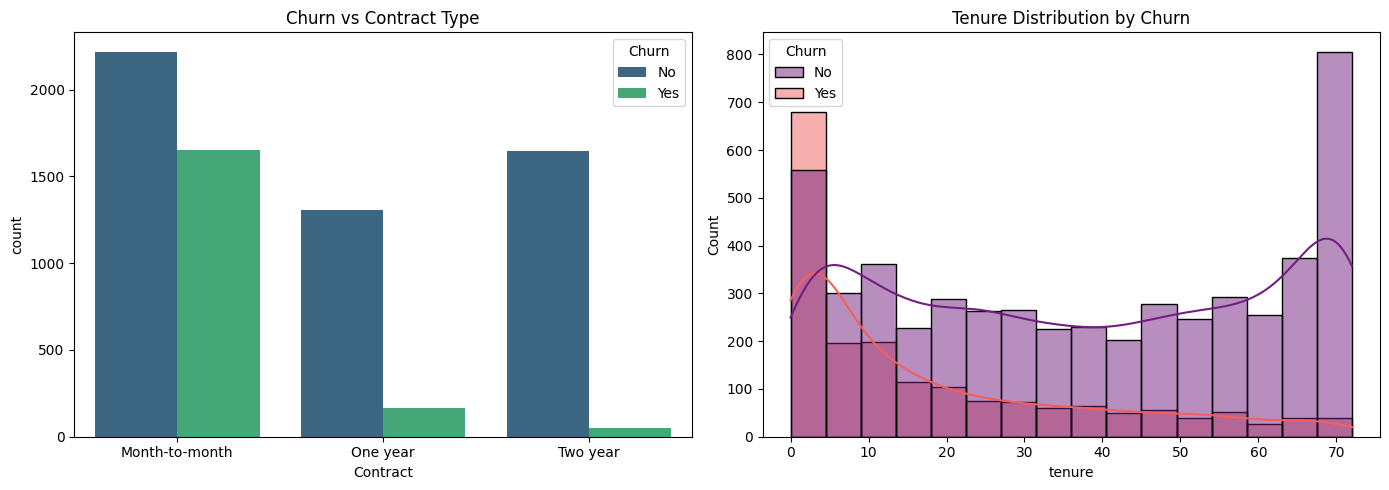

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA 
# Using a direct URL to bypass the "EmptyDataError" from your local file
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(url)
    print("✅ Data loaded successfully from remote source!")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# 2. DATA CLEANING
# Convert TotalCharges to numeric (it has empty strings ' ' that cause issues)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the 11 missing values created by the conversion with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop CustomerID as it's just a unique identifier
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 3. BASIC EXPLORATION
print("\n--- Dataset Summary ---")
print(df.info())
print("\n--- Churn Distribution ---")
print(df['Churn'].value_counts(normalize=True))

# 4. INITIAL EDA VISUALS
plt.figure(figsize=(14, 5))

# Plot 1: Churn by Contract Type (Strongest predictor)
plt.subplot(1, 2, 1)
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn vs Contract Type')

# Plot 2: Tenure Distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='magma')
plt.title('Tenure Distribution by Churn')

plt.tight_layout()
plt.show()

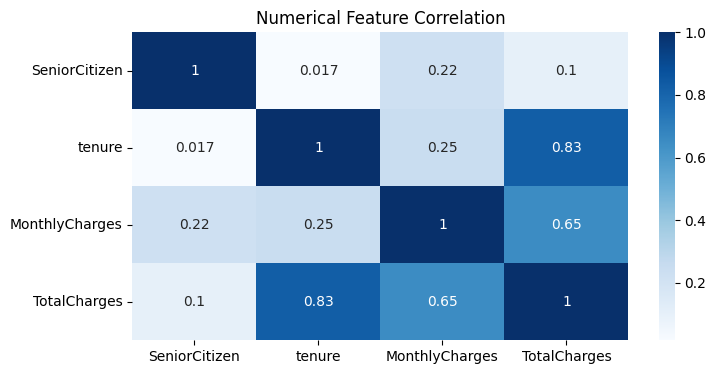

In [8]:
# Quick correlation check for numerical values
plt.figure(figsize=(8, 4))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='Blues')
plt.title('Numerical Feature Correlation')
plt.show()

Section 1: Data Cleaning & Missing Values

In [13]:
# Convert Churn to binary for correlation analysis later
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Ensure TotalCharges is a float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values (only 11 rows usually) with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

Missing values after cleaning: 0


Section 2: Feature Exploration

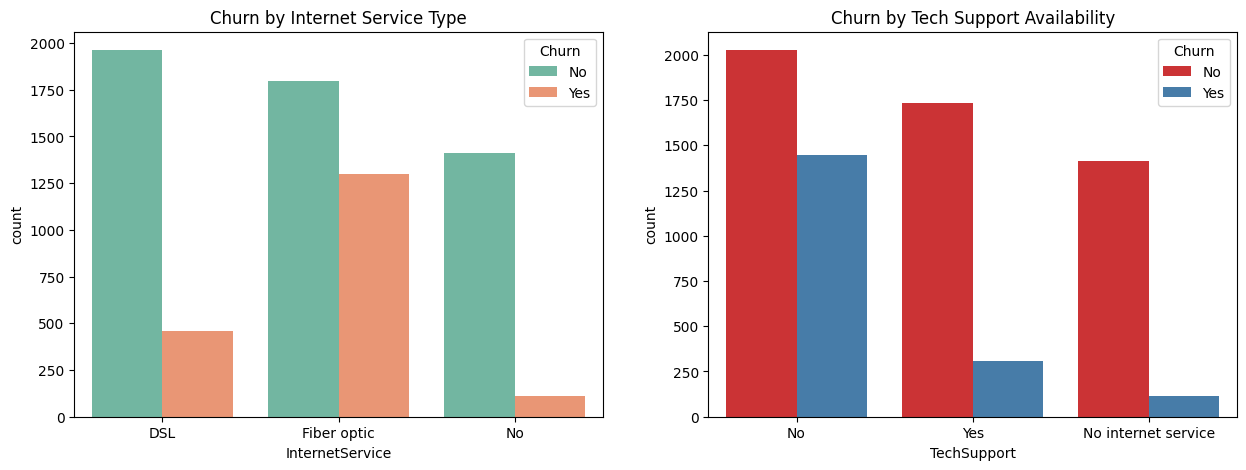

In [11]:
# Create a figure to compare multiple features
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Insight 1: Impact of Internet Service Type
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Internet Service Type')

# Insight 2: Impact of Technical Support
sns.countplot(x='TechSupport', hue='Churn', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Churn by Tech Support Availability')

plt.show()

Section 3: Correlation & Pattern Analysis

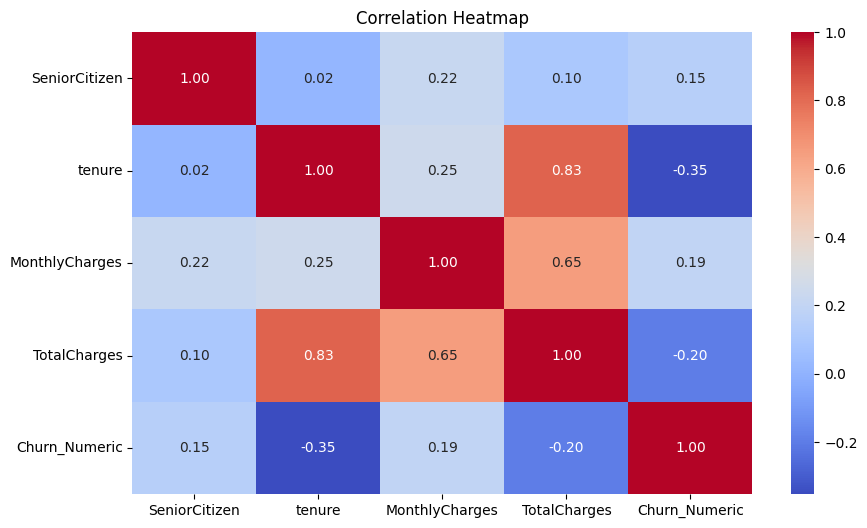

In [12]:
plt.figure(figsize=(10, 6))
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Section 4: Identification of Key Churn Factors

Explanation of Insights:

1. The "Contract" Factor

The data shows that Month-to-month customers have a significantly higher churn rate compared to those on one or two-year contracts.

Action: Offer discounts to move month-to-month users to annual plans.

2. The "Fiber Optic" Paradox

Surprisingly, Fiber Optic users often show higher churn rates than DSL users.

Insight: This suggests either the price point is too high or there are technical stability issues with the fiber rollout that need investigation.

3. The "Tenure" Threshold

There is a strong negative correlation between tenure and churn (r≈−0.35).

Insight: If a customer stays past the 6-month mark, their likelihood of leaving drops by over 50%. The first 90 days are the "danger zone."

4. Digital Behavior

Customers using Electronic Check as a payment method churn much more frequently than those using automated Credit Card or Bank Transfers.

Insight: Manual payment methods provide a "monthly decision point" where a customer reconsidering their bill is more likely to cancel.